# Part 1: DICOM Loading and Visualization

In [1]:
import sys
from utils import *
import matplotlib.pyplot as plt
import numpy as np
import pydicom
from pathlib import Path
import os

## a) Load both DICOM images

In [2]:
# Load both images — done once, reused throughout the notebook
mr_dcm  = load_dicom(MR_PATH)
pet_dcm = load_dicom(PET_PATH)

mr_volume  = mr_dcm.pixel_array   
mr_spacing = get_voxel_spacing(mr_dcm)

print("=== MR Image ===")
print(f"  File     : {MR_PATH.name}")
print(f"  Shape    : {mr_volume.shape}  (slices, rows, cols)")
print(f"  Modality : {mr_dcm.Modality}")
print(f"  Spacing  : dz={mr_spacing[0]} mm, dy={mr_spacing[1]} mm, dx={mr_spacing[2]} mm")

print("\n=== PET Image (raw) ===")
print(f"  File     : {PET_PATH.name}")
print(f"  Shape    : {pet_dcm.pixel_array.shape}  (total_slices, rows, cols) not yet rearranged")
print(f"  Modality : {pet_dcm.Modality}")

=== MR Image ===
  File     : 15252129_s1_AX_3D_T1__C_FSPGR_FORISI260916
  Shape    : (156, 256, 256)  (slices, rows, cols)
  Modality : MR
  Spacing  : dz=1.0 mm, dy=1.0 mm, dx=1.0 mm

=== PET Image (raw) ===
  File     : 02324177_s2_e_1_BRAIN_DINAMIC_COLINA_AC_FORISI260916
  Shape    : (1692, 256, 256)  (total_slices, rows, cols) not yet rearranged
  Modality : PT


## b) Study relevant DICOM headers


In [3]:
print("=== MR — Spatial Headers ===")
print(f"  (0028,0008) Number of Frames      : {getattr(mr_dcm, 'NumberOfFrames', 'N/A')}")
print(f"  (0028,0010) Rows                  : {mr_dcm.Rows}")
print(f"  (0028,0011) Columns               : {mr_dcm.Columns}")
print(f"  (0028,0030) Pixel Spacing (dy,dx) : {list(mr_dcm.PixelSpacing)} mm")
print(f"  (0018,0050) Slice Thickness       : {mr_dcm.SliceThickness} mm")
print(f"  (0018,0088) Spacing Between Slices: {getattr(mr_dcm, 'SpacingBetweenSlices', 'N/A')} mm")
print(f"  (0020,0037) Image Orientation     : {getattr(mr_dcm, 'ImageOrientationPatient', 'N/A')}")
print(f"  (0020,0032) Image Position        : {getattr(mr_dcm, 'ImagePositionPatient', 'N/A')}")

=== MR — Spatial Headers ===
  (0028,0008) Number of Frames      : 156
  (0028,0010) Rows                  : 256
  (0028,0011) Columns               : 256
  (0028,0030) Pixel Spacing (dy,dx) : ['1.0', '1.0'] mm
  (0018,0050) Slice Thickness       : 1.0 mm
  (0018,0088) Spacing Between Slices: 1.0 mm
  (0020,0037) Image Orientation     : N/A
  (0020,0032) Image Position        : N/A


In [4]:
print("=== PET — Spatial Headers ===")
print(f"  (0028,0008) Number of Frames      : {pet_dcm.NumberOfFrames}")
print(f"  (0028,0010) Rows                  : {pet_dcm.Rows}")
print(f"  (0028,0011) Columns               : {pet_dcm.Columns}")
print(f"  (0028,0030) Pixel Spacing (dy,dx) : {list(pet_dcm.PixelSpacing)} mm")
print(f"  (0018,0050) Slice Thickness       : {pet_dcm.SliceThickness} mm")
print(f"  (0018,0088) Spacing Between Slices: {getattr(pet_dcm, 'SpacingBetweenSlices', 'N/A')} mm")

print("\n=== PET — Temporal Headers (private tags) ===")
frame_times     = list(pet_dcm[0x0055, 0x1001].value)
frame_durations = list(pet_dcm[0x0055, 0x1004].value)
frame_positions = list(pet_dcm[0x0055, 0x1002].value)

print(f"  (0055,1001) Frame Start Times (s) : {frame_times[:8]} ... [{len(frame_times)} frames]")
print(f"  (0055,1004) Frame Durations  (ms) : {frame_durations[:8]} ... [{len(frame_durations)} frames]")
print(f"  (0055,1002) Frame Positions       : {frame_positions[:4]} ... [{len(frame_positions)} positions]")

print(f"\n  - Total frames: {len(frame_times)}")
print(f"  - Total raw slices: {pet_dcm.pixel_array.shape[0]}")
print(f"  - Slices per frame: {pet_dcm.pixel_array.shape[0] // len(frame_times)}")



=== PET — Spatial Headers ===
  (0028,0008) Number of Frames      : 1692
  (0028,0010) Rows                  : 256
  (0028,0011) Columns               : 256
  (0028,0030) Pixel Spacing (dy,dx) : ['1.171875', '1.171875'] mm
  (0018,0050) Slice Thickness       : 3.27 mm
  (0018,0088) Spacing Between Slices: 3.27 mm

=== PET — Temporal Headers (private tags) ===
  (0055,1001) Frame Start Times (s) : [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0] ... [36 frames]
  (0055,1004) Frame Durations  (ms) : [5000.0, 5000.0, 5000.0, 5000.0, 5000.0, 5000.0, 5000.0, 5000.0] ... [36 frames]
  (0055,1002) Frame Positions       : [-149.4140625, -149.4140625, -170.41999816894, -149.4140625] ... [5076 positions]

  - Total frames: 36
  - Total raw slices: 1692
  - Slices per frame: 47


## b) Visualize both images

**MR strategy:** 3 median planes (axial, coronal, sagittal) — MR has isotropic voxels (1mm³) so all planes have equal resolution and can be shown simultaneously.

**PET strategy (raw, before rearrangement):** Single axial slice at different positions in the raw array, to understand the flat `(1692, 256, 256)` structure before processing.

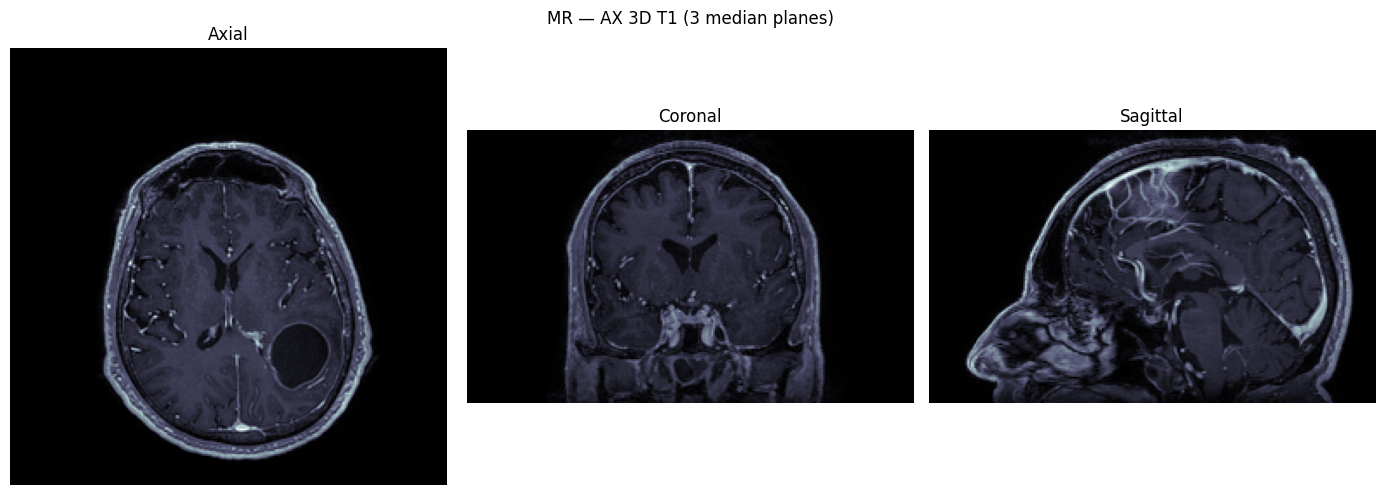

In [5]:
show_three_planes(mr_volume, title="MR — AX 3D T1 (3 median planes)", cmap="bone", voxel_spacing=mr_spacing)

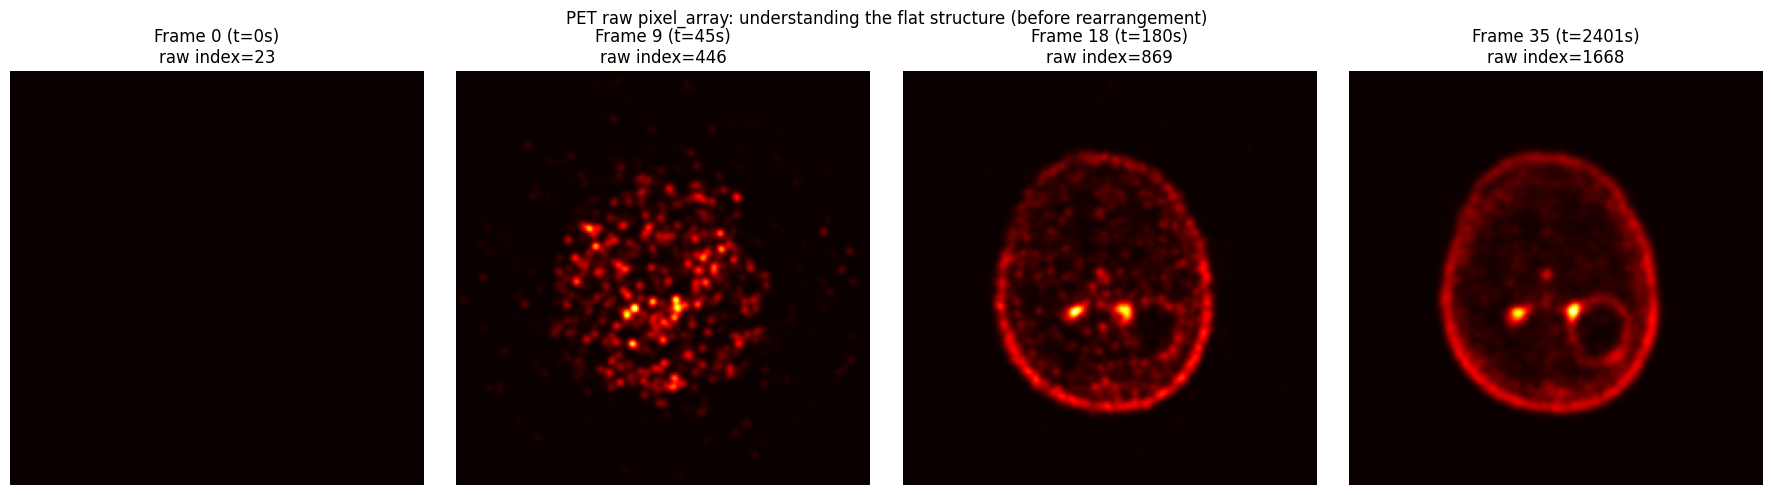

Raw structure: 36 frames x 47 slices = 1692 total slices


In [6]:
# Show raw PET structure BEFORE rearrangement
# Each block of 47 consecutive raw slices = 1 time frame
raw = pet_dcm.pixel_array  # (1692, 256, 256)
n_frames = len(frame_times)
n_slices_per_frame = raw.shape[0] // n_frames

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("PET raw pixel_array: understanding the flat structure (before rearrangement)\n")

mid_slice = n_slices_per_frame // 2  # middle slice within each frame

# Frame 0 (t=0s), Frame 9 (t=45s), Frame 18 (t=180s), Frame 35 (t=2401s)
for ax, frame_idx, label in zip(axes,
    [0, 9, 18, 35],
    ["Frame 0 (t=0s)", "Frame 9 (t=45s)", "Frame 18 (t=180s)", "Frame 35 (t=2401s)"]):
    raw_idx = frame_idx * n_slices_per_frame + mid_slice
    ax.imshow(raw[raw_idx], cmap="hot")
    ax.set_title(f"{label}\nraw index={raw_idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()
print(f"Raw structure: {n_frames} frames x {n_slices_per_frame} slices = {raw.shape[0]} total slices")

## c) Rearrange the PET pixel array


In [7]:
pet_4d, meta = rearrange_pet(pet_dcm)
pet_spacing  = meta['voxel_spacing']

print("=== PET after rearrangement ===")
print(f"  Shape: {pet_4d.shape}  (n_frames, n_slices, rows, cols)")
print(f"  Number of time frames : {meta['n_timeframes']}")
print(f"  Slices per frame      : {meta['n_slices']}")
print(f"  Voxel spacing (dz,dy,dx): {pet_spacing} mm ")
print(f"  Frame start times (s) : {meta['frame_times_s']}")
print(f"  Frame durations   (s) : {meta['frame_durations_s']}")

# Sanity check
rows, cols = pet_dcm.Rows, pet_dcm.Columns
assert pet_4d.shape == (meta['n_timeframes'], meta['n_slices'], rows, cols), \
    f"Shape mismatch: expected ({meta['n_timeframes']}, {meta['n_slices']}, {rows}, {cols}), got {pet_4d.shape}"
print("\n Shape assertion passed")

=== PET after rearrangement ===
  Shape: (36, 47, 256, 256)  (n_frames, n_slices, rows, cols)
  Number of time frames : 36
  Slices per frame      : 47
  Voxel spacing (dz,dy,dx): (3.27, 1.171875, 1.171875) mm 
  Frame start times (s) : [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 60.0, 70.0, 80.0, 90.0, 110.0, 130.0, 150.0, 180.0, 210.0, 240.0, 270.0, 300.0, 360.0, 420.0, 480.0, 540.0, 600.0, 750.0, 900.0, 1051.0, 1201.0, 1501.0, 1801.0, 2101.0, 2401.0]
  Frame durations   (s) : [5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 10.0, 10.0, 10.0, 10.0, 20.0, 20.0, 20.0, 30.0, 30.0, 30.0, 30.0, 30.0, 60.0, 60.0, 60.0, 60.0, 60.0, 150.0, 150.0, 150.0, 150.0, 300.0, 300.0, 300.0, 300.0, 300.0]

 Shape assertion passed


## d) Visualize last and average PET frames



Last frame: t=2401.0s, duration=300.0s


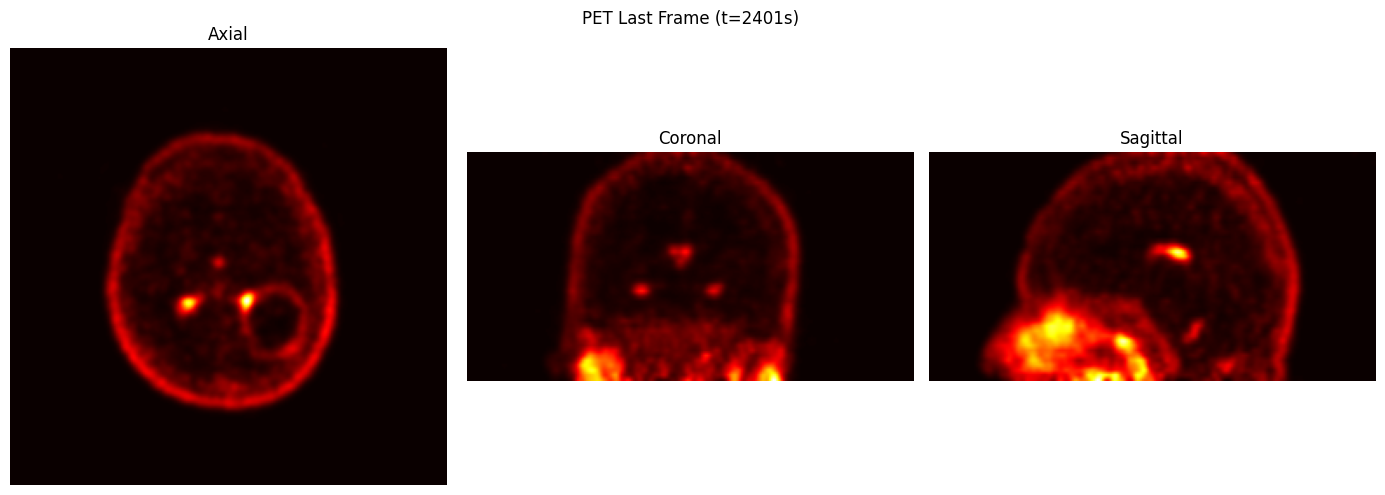

In [8]:
# Last frame: t = 2401s, duration = 300s — maximum tracer uptake
last_frame = pet_4d[-1]  # (47, 256, 256)
print(f"Last frame: t={meta['frame_times_s'][-1]}s, duration={meta['frame_durations_s'][-1]}s")
show_three_planes(last_frame, title="PET Last Frame (t=2401s)",
                  cmap="hot", voxel_spacing=pet_spacing)

PET average shape: (47, 256, 256)


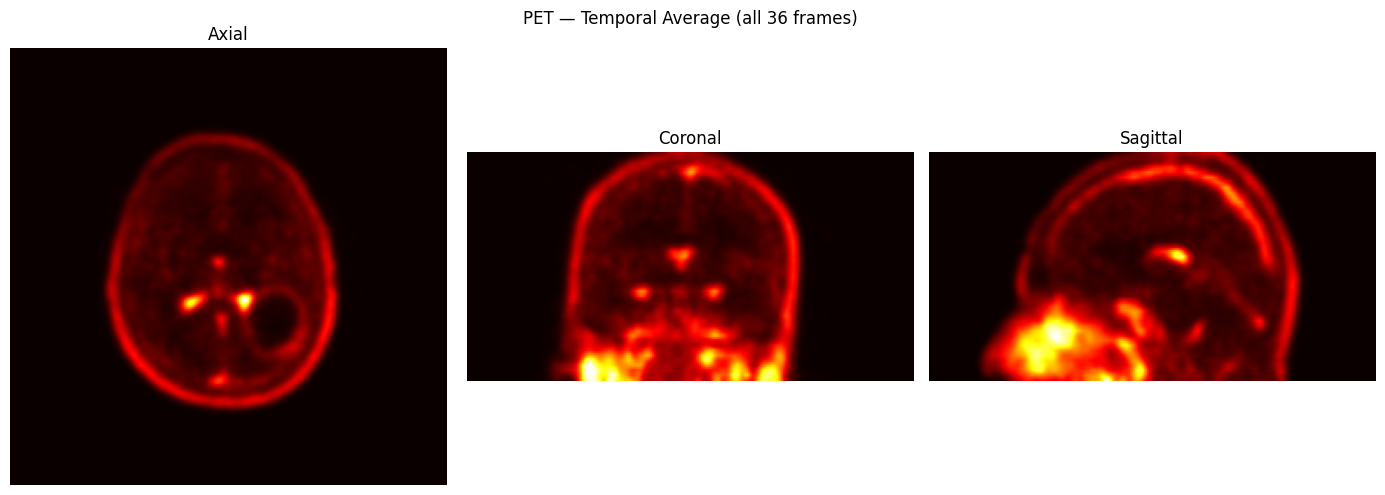

In [9]:
# Temporal average across all 36 frames
pet_avg = np.mean(pet_4d, axis=0).astype(np.float32)  
print(f"PET average shape: {pet_avg.shape}")
show_three_planes(pet_avg, title="PET — Temporal Average (all 36 frames)",
                  cmap="hot", voxel_spacing=pet_spacing)

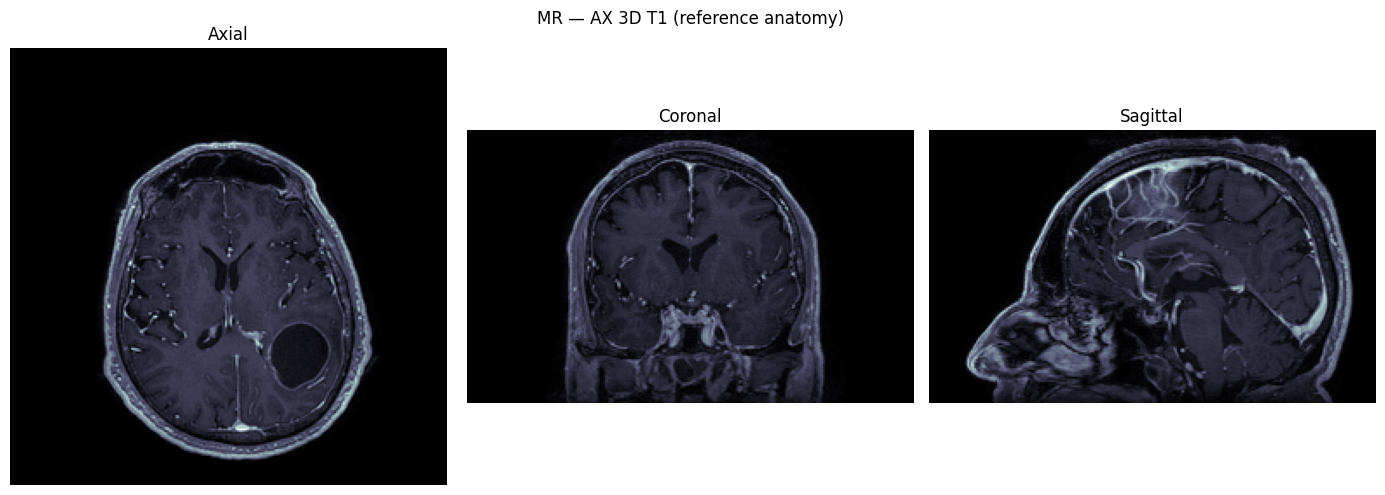

=== Comparison: PET vs MR ===
  PET: (47, 256, 256)  voxels, spacing=(3.27, 1.171875, 1.171875) mm  => anisotropic (dz=3.27mm)
  MR:  (156, 256, 256)  voxels, spacing=(1.0, 1.0, 1.0) mm => isotropic  (1mm)
  => Different voxel sizes means coregistration must work in physical (mm) space


In [10]:
# MR for comparison
show_three_planes(mr_volume, title="MR — AX 3D T1 (reference anatomy)",
                  cmap="bone", voxel_spacing=mr_spacing)

print("=== Comparison: PET vs MR ===")
print(f"  PET: {pet_4d.shape[1:]}  voxels, spacing={pet_spacing} mm  => anisotropic (dz=3.27mm)")
print(f"  MR:  {mr_volume.shape}  voxels, spacing={mr_spacing} mm => isotropic  (1mm)")
print("  => Different voxel sizes means coregistration must work in physical (mm) space")

## e) Animations


GIF saved to Data/outputs/pet_dynamic_planes.gif


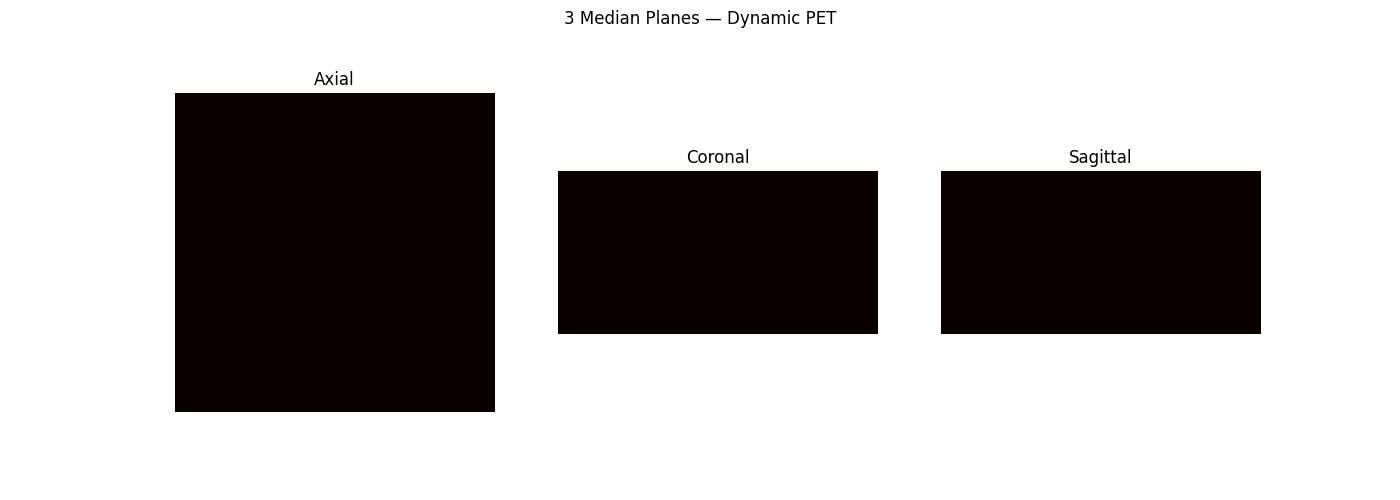

In [11]:
os.makedirs("Data/outputs", exist_ok=True)

save_gif_three_planes(
    pet_4d,
    voxel_spacing=pet_spacing,
    cmap="hot",
    output_path="Data/outputs/pet_dynamic_planes.gif",
    interval=200
)
display_gif("Data/outputs/pet_dynamic_planes.gif")